# Univariate Analysis: Airbnb Cleaned Dataset
exploring the distribution and characteristics of single variables in the airbnb dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('airbnb_cleaned.csv')

df.head()

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,latitude,longitude,borough,neighbourhood,is_rated
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private Room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,40.63222,-73.93398,Brooklyn,Flatlands,1
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire place,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,40.78761,-73.96862,Manhattan,Upper West Side,1
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire place,150.0,0,NaN,0.00,65,NaN,0.0,0.000000,2018-08-15,40.70070,-73.99517,Brooklyn,Brooklyn Heights,0
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire place,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,40.79169,-73.97498,Manhattan,Upper West Side,1
4,271954,Beautiful brownstone apartment,1423798,Aj,Entire place,150.0,203,2019-06-20,2.22,300,4.478396,243.6,0.743500,2018-12-15,40.73388,-73.99452,Manhattan,Greenwich Village,1


## Descriptive Statistics
just like in Exercise 8, we're gonna group our data by a category and calculate things like **skewness** and **kurtosis**. 

let's group the Airbnb **prices** by **borough** to see how the distributions look across different areas of New York.

In [ ]:
grouped_price = df.groupby('borough')['price']

grouped_summary = grouped_price.describe()

# skewness and kurtosis
grouped_summary['Skewness'] = grouped_price.apply(lambda x: x.skew())
grouped_summary['Kurtosis'] = grouped_price.apply(lambda x: x.kurt())

grouped_summary

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
borough,,,,,,,,,,
Bronx,229.0,89.229784,98.700546,20.0,45.0,65.0,99.0,1000.0,5.429980,39.105729
Brooklyn,4079.0,124.171083,185.171578,0.0,60.0,95.0,150.0,8000.0,25.176000,936.236638
Manhattan,4439.0,193.773948,234.571682,0.0,96.0,150.0,220.0,5250.0,9.577052,140.327038
Queens,1180.0,98.012440,102.853487,10.0,50.0,75.0,115.0,2000.0,10.342968,165.812617
Staten Island,73.0,93.941306,59.089307,29.0,50.0,75.0,118.0,300.0,1.579891,2.878974


## Cross-Sectional Plots
Now, let's add some visual distributions to interpret the statistical results above. We'll look at histograms and boxplots.

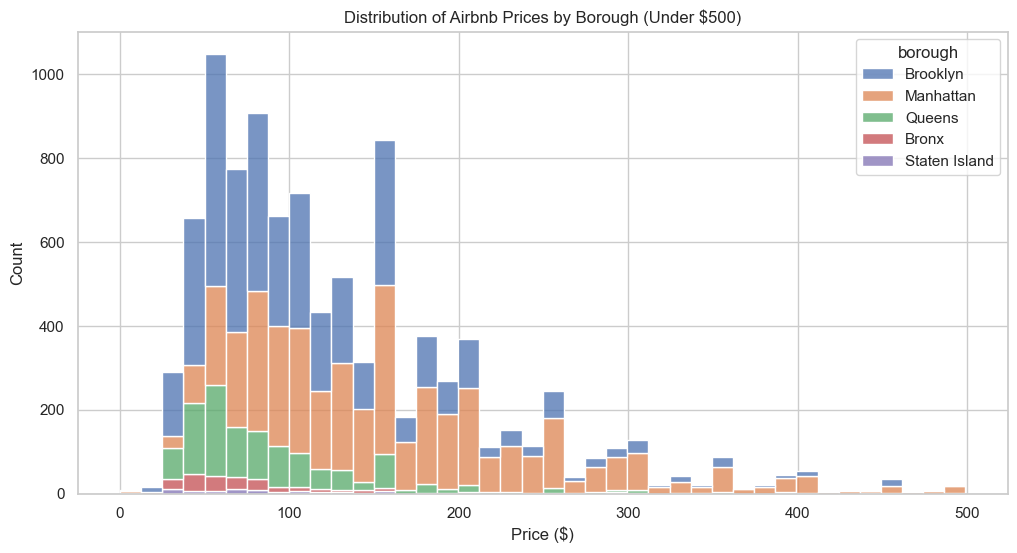

In [3]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Plot 1: Histogram of Prices (Filtered to < $500 for better visibility)
plt.figure(figsize=(12, 6))
sns.histplot(data=df[df['price'] < 500], x='price', hue='borough', multiple='stack', bins=40)
plt.title('Distribution of Airbnb Prices by Borough (Under $500)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

C:\Users\monik\AppData\Local\Temp\ipykernel_25688\782212526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='rating', palette='Set2')


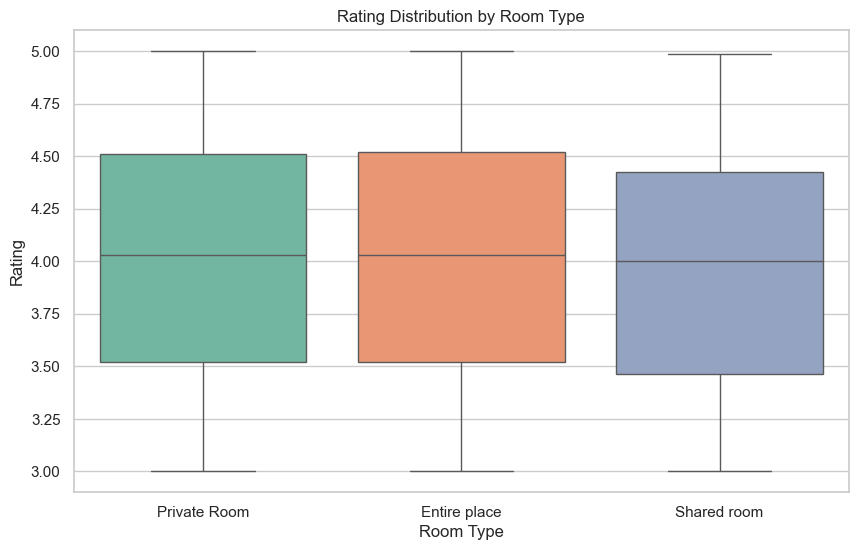

In [4]:
# Plot 2: Boxplot of Ratings by Room Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='room_type', y='rating', palette='Set2')
plt.title('Rating Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Rating')
plt.show()

### Interpretation of Results:
* **Price Skewness:** Most boroughs will likely show a positive skew in price (a long tail to the right), meaning the majority of listings are clustered around lower/average prices, but a few extremely expensive listings pull the mean up.
* **Kurtosis:** High kurtosis indicates "heavy tails" (more outliers than a normal distribution).
* **Ratings:** The boxplot visually demonstrates the median rating, the interquartile range (where 50% of the data lives), and highlights any extremely low-rated outliers.